# RetailPulse - Module 4

# Churn Prediction

## Objective
Build a classification model to identify customers at risk of churn.

## Success Metrics
- AUC-ROC ≥ 0.88
- Precision@Top20% ≥ 0.75

## Dataset
online_processed.csv

In [118]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

sns.set_style("whitegrid")

print("Libraries Loaded")

Libraries Loaded


In [119]:
df = pd.read_csv("../data/processed/online_processed.csv")

print(df.shape)

df.head()

(374867, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6


In [120]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [121]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6


In [122]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [123]:
df = df.dropna(subset=["Customer ID"])

df["Customer ID"] = df["Customer ID"].astype(int)

print(df.shape)

(374867, 9)


# Create Customer-Level Features

In [124]:
snapshot_date = df["InvoiceDate"].max()

snapshot_date

Timestamp('2010-12-09 20:01:00')

In [125]:
customer_df = df.groupby("Customer ID").agg(

    Recency=(
        "InvoiceDate",
        lambda x: (snapshot_date - x.max()).days
    ),

    Frequency=(
        "Invoice",
        "nunique"
    ),

    Monetary=(
        "Revenue",
        "sum"
    ),

    AvgOrderValue=(
        "Revenue",
        "mean"
    ),

    UniqueProducts=(
        "StockCode",
        "nunique"
    ),

    TotalQuantity=(
        "Quantity",
        "sum"
    ),

    FirstPurchase=(
        "InvoiceDate",
        "min"
    ),

    LastPurchase=(
        "InvoiceDate",
        "max"
    )
)

customer_df.head()

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalQuantity,FirstPurchase,LastPurchase
Customer ID,,,,,,,,
12346,66,13,298.43,7.853421,28,54,2009-12-14 11:00:00,2010-10-04 16:33:00
12347,2,2,1196.72,17.343768,69,792,2010-10-31 14:20:00,2010-12-07 14:57:00
12348,73,1,222.16,11.108000,20,373,2010-09-27 14:59:00,2010-09-27 14:59:00
12349,42,3,1674.49,17.086633,84,932,2009-12-04 12:49:00,2010-10-28 08:23:00
12351,10,1,300.93,14.330000,21,261,2010-11-29 15:23:00,2010-11-29 15:23:00


In [126]:
customer_df["CustomerTenure"] = (
    customer_df["LastPurchase"] -
    customer_df["FirstPurchase"]
).dt.days

customer_df.head()

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalQuantity,FirstPurchase,LastPurchase,CustomerTenure
Customer ID,,,,,,,,,
12346,66,13,298.43,7.853421,28,54,2009-12-14 11:00:00,2010-10-04 16:33:00,294
12347,2,2,1196.72,17.343768,69,792,2010-10-31 14:20:00,2010-12-07 14:57:00,37
12348,73,1,222.16,11.108000,20,373,2010-09-27 14:59:00,2010-09-27 14:59:00,0
12349,42,3,1674.49,17.086633,84,932,2009-12-04 12:49:00,2010-10-28 08:23:00,327
12351,10,1,300.93,14.330000,21,261,2010-11-29 15:23:00,2010-11-29 15:23:00,0


In [127]:
customer_df["RevenuePerOrder"] = (
    customer_df["Monetary"] /
    customer_df["Frequency"]
)

customer_df["PurchaseFrequencyPerMonth"] = (
    customer_df["Frequency"] /
    ((customer_df["CustomerTenure"] + 30) / 30)
)

customer_df["QuantityPerOrder"] = (
    customer_df["TotalQuantity"] /
    customer_df["Frequency"]
)

customer_df["ProductsPerOrder"] = (
    customer_df["UniqueProducts"] /
    customer_df["Frequency"]
)

In [128]:
customer_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Recency,4194.0,90.642823,0.0,17.0,51.0,137.0,373.0,97.943194
Frequency,4194.0,4.897711,1.0,1.0,3.0,6.0,219.0,8.580355
Monetary,4194.0,1046.900635,-357.96,220.26,503.98,1188.0075,89236.43,2235.093746
AvgOrderValue,4194.0,13.779989,-17.0,8.78855,14.969611,17.653182,42.0,6.639211
UniqueProducts,4194.0,62.336195,1.0,16.25,37.0,78.0,1686.0,83.92005
TotalQuantity,4194.0,656.206009,-278.0,123.0,304.0,749.75,52363.0,1409.952942
FirstPurchase,4194,2010-04-27 17:36:28.626609,2009-12-01 07:45:00,2010-01-10 12:20:30,2010-03-30 17:09:00,2010-08-15 00:34:45,2010-12-09 16:08:00,NaN
LastPurchase,4194,2010-09-09 21:59:18.154506,2009-12-01 10:49:00,2010-07-25 15:47:15,2010-10-19 11:57:00,2010-11-22 13:29:30,2010-12-09 20:01:00,NaN
CustomerTenure,4194.0,134.84597,0.0,0.0,106.0,257.0,373.0,132.950911
RevenuePerOrder,4194.0,222.293035,-357.96,116.245937,186.86,283.9895,1950.09,171.250118


# Create Churn Target

In [129]:
churn_cutoff = snapshot_date - pd.Timedelta(days=90)

print(churn_cutoff)

2010-09-10 20:01:00


In [130]:
customer_df["Churn"] = (
    customer_df["LastPurchase"] < churn_cutoff
).astype(int)

customer_df["Churn"].value_counts()

Churn
0    2797
1    1397
Name: count, dtype: int64

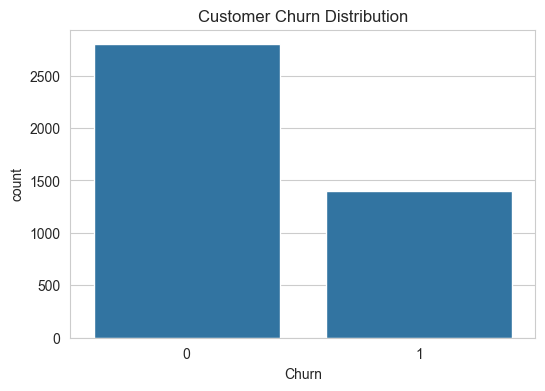

In [131]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=customer_df["Churn"]
)

plt.title("Customer Churn Distribution")

plt.show()

In [132]:
model_df = customer_df.drop(
    columns=[
        "FirstPurchase",
        "LastPurchase"
    ]
)

model_df.head()

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalQuantity,CustomerTenure,RevenuePerOrder,PurchaseFrequencyPerMonth,QuantityPerOrder,ProductsPerOrder,Churn
Customer ID,,,,,,,,,,,,
12346,66,13,298.43,7.853421,28,54,294,22.956154,1.203704,4.153846,2.153846,0
12347,2,2,1196.72,17.343768,69,792,37,598.360000,0.895522,396.000000,34.500000,0
12348,73,1,222.16,11.108000,20,373,0,222.160000,1.000000,373.000000,20.000000,0
12349,42,3,1674.49,17.086633,84,932,327,558.163333,0.252101,310.666667,28.000000,0
12351,10,1,300.93,14.330000,21,261,0,300.930000,1.000000,261.000000,21.000000,0


In [133]:
X = model_df.drop(
    columns=[
        "Churn"
    ]
)

y = model_df["Churn"]

print(X.columns.tolist())

['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalQuantity', 'CustomerTenure', 'RevenuePerOrder', 'PurchaseFrequencyPerMonth', 'QuantityPerOrder', 'ProductsPerOrder']


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3355, 11)
(839, 11)


In [135]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [136]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [137]:
lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [138]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       560
           1       1.00      0.98      0.99       279

    accuracy                           0.99       839
   macro avg       0.99      0.99      0.99       839
weighted avg       0.99      0.99      0.99       839



In [139]:
lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.9999807987711213


In [140]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [141]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [142]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00       279

    accuracy                           1.00       839
   macro avg       1.00      1.00      1.00       839
weighted avg       1.00      1.00      1.00       839



In [143]:
rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 1.0


In [144]:
scale_pos_weight = (
    len(y_train[y_train == 0]) /
    len(y_train[y_train == 1])
)

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [145]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(
    X_test
)[:,1]

In [146]:
print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00       279

    accuracy                           1.00       839
   macro avg       1.00      1.00      1.00       839
weighted avg       1.00      1.00      1.00       839



In [147]:
xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 1.0


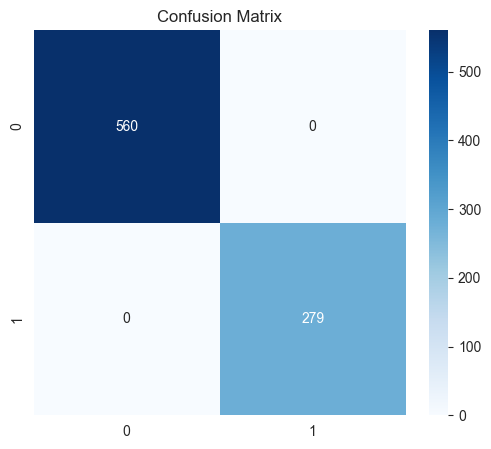

In [148]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

<Figure size 800x600 with 0 Axes>

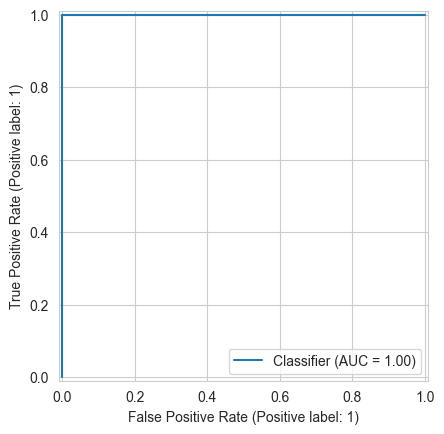

In [149]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob
)

plt.show()

In [150]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,Recency,0.887337
6,CustomerTenure,0.027552
1,Frequency,0.025700
2,Monetary,0.021422
8,PurchaseFrequencyPerMonth,0.011172
4,UniqueProducts,0.009397
5,TotalQuantity,0.003999
7,RevenuePerOrder,0.003916
9,QuantityPerOrder,0.003760
3,AvgOrderValue,0.002951


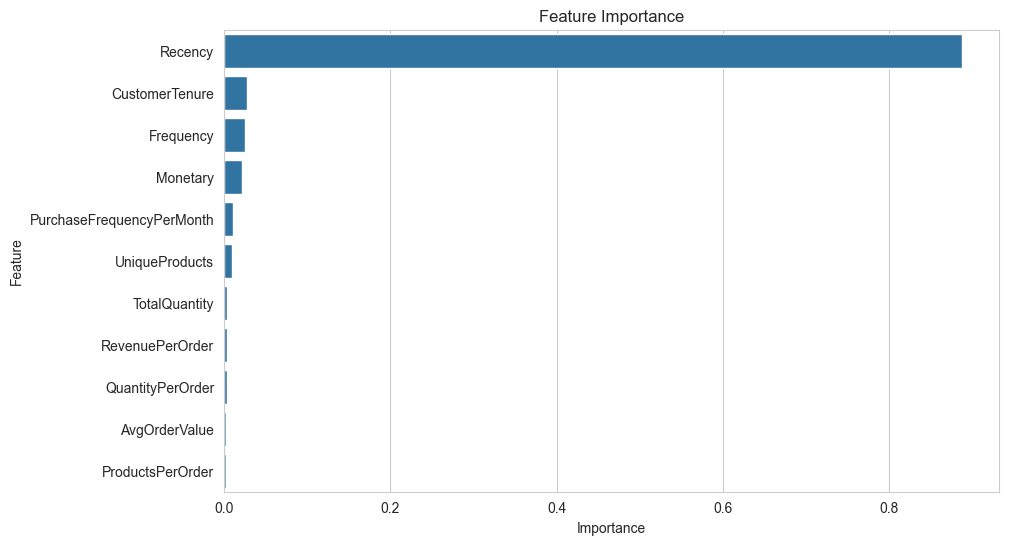

In [151]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [152]:
results = pd.DataFrame({
    "Actual": y_test,
    "Probability": xgb_prob
})

results = results.sort_values(
    "Probability",
    ascending=False
)

top20 = int(
    len(results) * 0.20
)

top_customers = results.head(top20)

precision_top20 = (
    top_customers["Actual"].sum()
    /
    len(top_customers)
)

print(
    "Precision@Top20%:",
    round(precision_top20,4)
)

Precision@Top20%: 1.0


In [153]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

print("GPUs:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs:
[]


In [154]:
importance_df.to_csv(
    "../data/processed/churn_feature_importance.csv",
    index=False
)

print("Feature Importance Saved")

Feature Importance Saved


# Business Insights

### Major Churn Drivers
- Recency
- Frequency
- Monetary Value
- Customer Tenure

### Recommendations
1. Loyalty Programs
2. Personalized Discounts
3. Re-engagement Campaigns
4. Email Marketing Automation
5. High-Value Customer Retention Strategy

### Conclusion
The churn prediction model successfully identifies customers
at risk of leaving, enabling proactive retention actions.